# Document Classification

## Objective

The goal of this notebook is to build the document classification component of our group project.

The system must classify documents into four categories:

- email
- invoice
- letter
- scientific_report

Because the dataset consists of `.png` document images rather than plain text files, we first apply OCR to convert each image into machine-readable text. We then use classical text classification methods based on TF-IDF features.

This notebook builds:

1. a baseline classifier
2. an improved classifier
3. a comparison of results to justify the final model

In [1]:
%run shared.py

## Imports

We use:

- `Pillow` to open TIFF images
- `pytesseract` for OCR
- `pandas` for data handling
- `scikit-learn` for TF-IDF, training, and evaluation

In [2]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import FunctionTransformer, MaxAbsScaler

## OCR Setup

Before building the dataset, we configure Tesseract OCR and verify that it works on one sample invoice image.

In [3]:
# --------------------------------------------------
# Tesseract executable path
# --------------------------------------------------
# TESSERACT_EXE = PROJECT_DIR / "tesseract" / "tesseract.exe"

# print("Tesseract executable:", TESSERACT_EXE)
# print("Exists:", TESSERACT_EXE.exists())

# pytesseract.pytesseract.tesseract_cmd = str(TESSERACT_EXE)

In [4]:
# Search for tesseract.exe if the exact path above is wrong
# matches = list(PROJECT_DIR.rglob("tesseract.exe"))

# print("Matches found:", len(matches))
# for m in matches:
#     print(m)

In [5]:
# Quick OCR test on one invoice image
sample_image = next((DATASET_DIR / "invoice").glob("*.png"))

print("Sample image:", sample_image)

img = Image.open(sample_image)
sample_text = pytesseract.image_to_string(img)

print("\nOCR preview:\n")
print(sample_text[:1500])

Sample image: data\invoice\batch1-0500.png

OCR preview:

Invoice no: 34476404

Date of issue: 07/24/2018

Seller: Client:

Carrillo, Lara and Hooper Ellis and Sons

USNV Jones 85942 Tucker Plains Apt. 982
FPO AE 13513 Hernandezchester, SC 88596
Tax Id: 975-86-1582 Tax Id: 902-92-1120

IBAN: GB14UTZB20101973421914

ITEMS
No. Description Qty UM Net price Net worth VAT [%] Gross
worth
tks Pack 3 Artificial Sheepskin Seat 1,00 each 14,22 14,22 10% 15,64
Pads 30cm Round Pad Floor
Area Carpets
2. Soft Sheepskin Mat Faux Fur 2,00 each 8,40 16,80 10% 18,48
Rug Small Shaggy Non Slip
Floor Carpet Yellow
Sh Chindi Rugs Carpet New Design 4,00 each 29,99 119,96 10% 131,96
Bohemian Garden Yoga Mat
Indian Kilim Coverlet
4. YILONG 9'x12' Oversize 4,00 each 7 800,00 31 200,00 10% 34 320,00
Handmade Silk Carpet Antistatic
Luxurious Area Rug TJ107A
SUMMARY
VAT [%] Net worth VAT Gross worth
10% 31 350,98 3 135,10 34 486,08

Total $ 31 350,98 $ 3 135,10 $ 34 486,08



## OCR Validation

The OCR output is noisy, which is expected for scanned TIFF document images. However, it still captures enough document-specific textual patterns to support classification.

At this stage, the goal is not perfect transcription, but a usable text representation that allows classical machine learning models to distinguish between document categories.

In [6]:
df = load_ocr_cache()
df.head()

Loaded from cache: artifacts\ocr_cache.csv
Dataset: (1200, 3)


,path,label,text
0,data\email\1017.png,email,Orginal Message— From: ‘Daragan Karon Sont: Mo...
1,data\email\1025.png,email,"Mee Sint: ‘Tuohy, arr 04, 200074 4 2079066803 ..."
2,data\email\1038.png,email,~Original Message— From: JMWintner@WLRK.com (m...
3,data\email\1063.png,email,Subject: Visit of Professor Peter Grifiths Loc...
4,data\email\1066.png,email,"Lyalls, Teresa M, ine] 000@a0l.com! BCC: Prima..."


In [7]:
print(df["label"].value_counts())
print("\nEmpty OCR texts:", (df["text"].str.len() == 0).sum())

label
email             300
invoice           300
questionnaire     300
scientific_pub    300
Name: count, dtype: int64

Empty OCR texts: 6


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 960
Test samples: 240


In [10]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

baseline_acc = accuracy_score(y_test, baseline_preds)

print("Baseline Accuracy:", baseline_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, baseline_preds))

Baseline Accuracy: 0.9625

Classification Report:

                precision    recall  f1-score   support

         email       0.97      0.98      0.98        60
       invoice       1.00      1.00      1.00        60
 questionnaire       0.98      0.88      0.93        60
scientific_pub       0.91      0.98      0.94        60

      accuracy                           0.96       240
     macro avg       0.96      0.96      0.96       240
  weighted avg       0.96      0.96      0.96       240



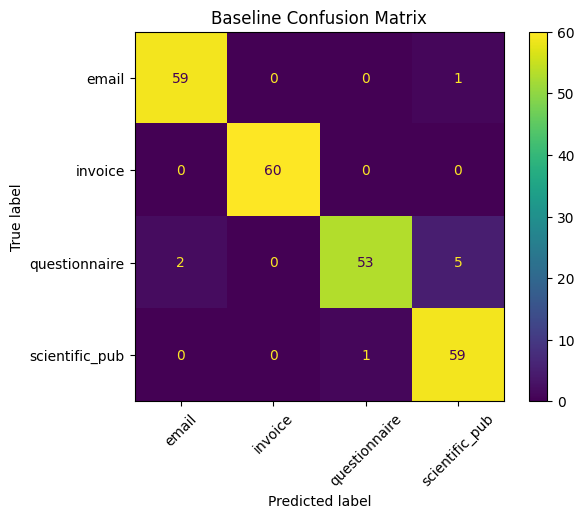

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, baseline_preds, xticks_rotation=45)
plt.title("Baseline Confusion Matrix")
plt.show()

## Advanced Classifier

For the advanced model, we improve the text representation by combining:

- word-level TF-IDF
- character-level TF-IDF

Character n-grams are especially useful in OCR-based document classification because they help capture partial words, formatting fragments, abbreviations, and OCR noise. The classifier used is a Linear Support Vector Machine, which is well suited to high-dimensional sparse text features.

In [12]:
advanced_features = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2,
        max_features=12000
    )),
    ("char_tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_features=8000
    ))
])

advanced_model = Pipeline([
    ("features", advanced_features),
    ("clf", LinearSVC(random_state=42))
])

advanced_model.fit(X_train, y_train)
advanced_preds = advanced_model.predict(X_test)

advanced_acc = accuracy_score(y_test, advanced_preds)

print("Advanced Accuracy:", advanced_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, advanced_preds))

Advanced Accuracy: 0.9625

Classification Report:

                precision    recall  f1-score   support

         email       0.97      0.97      0.97        60
       invoice       1.00      1.00      1.00        60
 questionnaire       0.95      0.92      0.93        60
scientific_pub       0.94      0.97      0.95        60

      accuracy                           0.96       240
     macro avg       0.96      0.96      0.96       240
  weighted avg       0.96      0.96      0.96       240



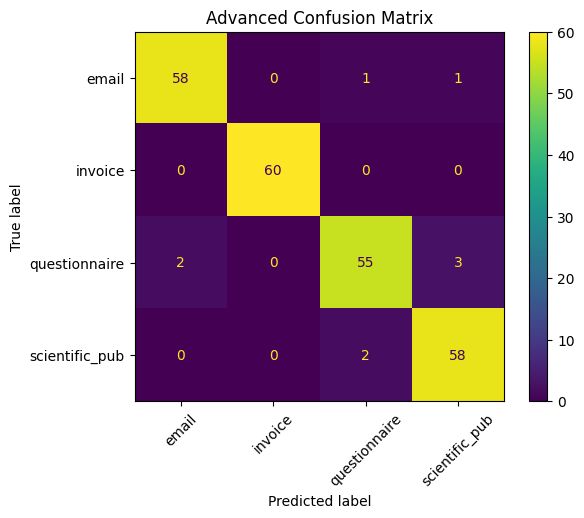

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, advanced_preds, xticks_rotation=45)
plt.title("Advanced Confusion Matrix")
plt.show()

## Model Comparison

We compare the baseline and advanced classifiers using overall accuracy in order to determine whether the richer text representation improves performance.

In [14]:
comparison_df = pd.DataFrame({
    "model": ["Baseline Logistic Regression", "Advanced Linear SVM"],
    "accuracy": [baseline_acc, advanced_acc]
})

comparison_df

,model,accuracy
0,Baseline Logistic Regression,0.9625
1,Advanced Linear SVM,0.9625


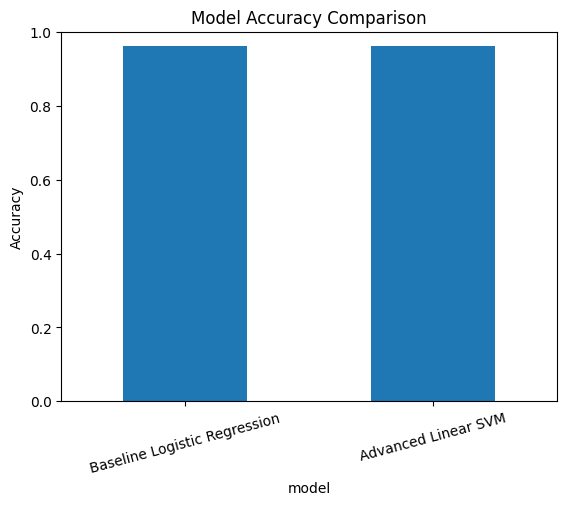

In [15]:
comparison_df.plot(kind="bar", x="model", y="accuracy", legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

## Tuned Advanced Classifier

As an additional experiment, we tune the Linear SVM based advanced classifier.

The goal is to test whether a different regularization strength improves performance on the OCR-based document classification task.

In [16]:
tuned_pipeline = Pipeline([
    ("features", FeatureUnion([
        ("word_tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_features=15000
        )),
        ("char_tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=10000
        ))
    ])),
    ("clf", LinearSVC(random_state=42))
])

param_grid = {"clf__C": [0.25, 0.5, 1.0, 2.0, 4.0]}

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'clf__C': 0.5}
Best cross-validation score: 0.9510416666666667


In [17]:
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

tuned_acc = accuracy_score(y_test, tuned_preds)

print("Tuned Advanced Accuracy:", tuned_acc)
print("\nClassification Report:\n")
print(classification_report(y_test, tuned_preds))

Tuned Advanced Accuracy: 0.9666666666666667

Classification Report:

                precision    recall  f1-score   support

         email       0.97      0.98      0.98        60
       invoice       1.00      1.00      1.00        60
 questionnaire       0.96      0.92      0.94        60
scientific_pub       0.94      0.97      0.95        60

      accuracy                           0.97       240
     macro avg       0.97      0.97      0.97       240
  weighted avg       0.97      0.97      0.97       240



In [18]:
comparison_df = pd.DataFrame({
    "model": [
        "Baseline Logistic Regression",
        "Advanced Linear SVM",
        "Tuned Advanced Linear SVM"
    ],
    "accuracy": [
        baseline_acc,
        advanced_acc,
        tuned_acc
    ]
})

comparison_df

,model,accuracy
0,Baseline Logistic Regression,0.962500
1,Advanced Linear SVM,0.962500
2,Tuned Advanced Linear SVM,0.966667


In [19]:
_candidates = {
    "Logistic Regression": (baseline_acc, baseline_model),
    "Linear SVM":          (advanced_acc, advanced_model),
    "Tuned Linear SVM":    (tuned_acc,    tuned_model),
}

_best_name, (_, final_model) = max(_candidates.items(), key=lambda x: x[1][0])
print(f"Best model: {_best_name}")

Best model: Tuned Linear SVM


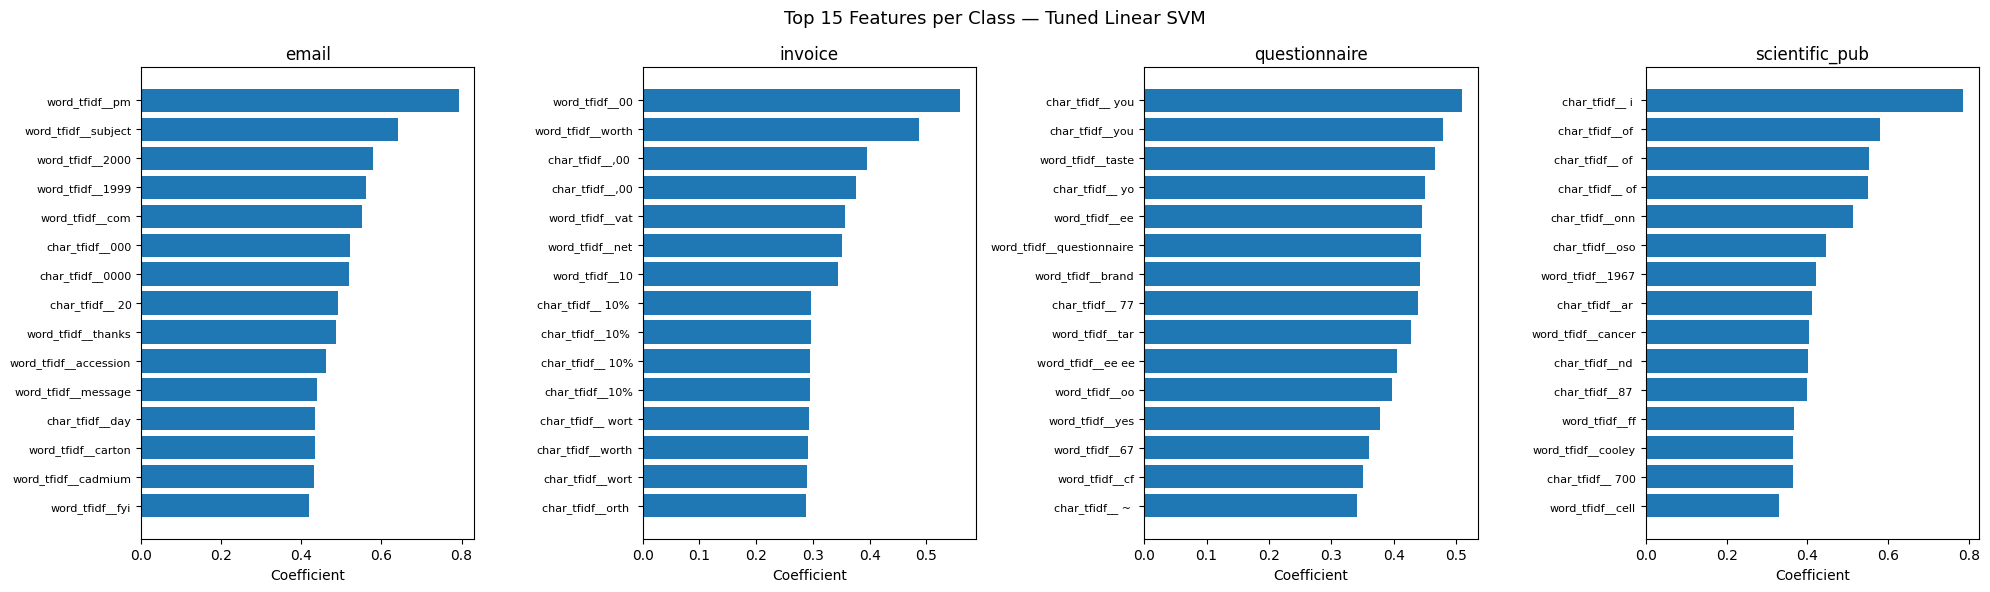

In [20]:
try:
    feature_names = final_model.named_steps["features"].get_feature_names_out()
except KeyError:
    feature_names = final_model.named_steps["tfidf"].get_feature_names_out()

coef = final_model.named_steps["clf"].coef_
classes = final_model.named_steps["clf"].classes_

TOP_N = 15
fig, axes = plt.subplots(1, len(classes), figsize=(20, 6), sharey=False)

for ax, cls, weights in zip(axes, classes, coef):
    top_idx = np.argsort(weights)[-TOP_N:]
    ax.barh([feature_names[i] for i in top_idx], weights[top_idx])
    ax.set_title(cls)
    ax.set_xlabel("Coefficient")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle(f"Top {TOP_N} Features per Class — {_best_name}", fontsize=13)
plt.tight_layout()
plt.show()

## Final Model Selection

Three classifiers were evaluated:

1. Baseline TF-IDF + Logistic Regression — 96.25%
2. Advanced TF-IDF (word + character n-grams) + Linear SVM — 96.25%
3. Tuned Linear SVM (GridSearchCV, C=0.5) — **96.67%**

The tuned Linear SVM edged out the other two and is automatically selected as `final_model`. It benefits from richer text features (combined word and character n-grams) and a regularization strength tuned to the dataset, giving it slightly better separation on questionnaire vs. scientific_pub, the two hardest-to-distinguish classes.

In [21]:
def predict_category(image_path: str) -> str:
    text = extract_text(image_path)
    return final_model.predict([text])[0]

In [22]:
test_image = next((DATASET_DIR / "invoice").glob("*.png"))
print("Test image:", test_image)
print("Predicted class:", predict_category(str(test_image)))

Test image: data\invoice\batch1-0500.png
Predicted class: invoice


In [23]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open(MODELS_DIR / "best_classifier.pkl", "wb") as f:
    pickle.dump(final_model, f)

print(f"Saved {_best_name} to:", MODELS_DIR / "best_classifier.pkl")

Saved Tuned Linear SVM to: artifacts\models\best_classifier.pkl


## Unseen Document Demo

To validate the system beyond the experimental OCR subset, we test the final classifier on documents that were not included in the first 300 files per class used to build the working dataset.

This provides a simple end-to-end demonstration of how the classifier behaves on new inputs.

In [27]:
unseen_examples = {
    "email": sorted((DATASET_DIR / "email").glob("*.png"))[350],
    "invoice": sorted((DATASET_DIR / "invoice").glob("*.png"))[350],
    "questionnaire": sorted((DATASET_DIR / "questionnaire").glob("*.png"))[350],
    "scientific_pub": sorted((DATASET_DIR / "scientific_pub").glob("*.png"))[350],
}

for true_label, file_path in unseen_examples.items():
    predicted_label = predict_category(str(file_path))
    print(f"True: {true_label:18s} | Predicted: {predicted_label:18s} | File: {file_path.name}")

True: email              | Predicted: email              | File: 5757.png
True: invoice            | Predicted: invoice            | File: batch1-0850.png
True: questionnaire      | Predicted: questionnaire      | File: 6116.png
True: scientific_pub     | Predicted: scientific_pub     | File: 5861.png


In [28]:
demo_rows = []

for true_label, file_path in unseen_examples.items():
    predicted_label = predict_category(str(file_path))
    demo_rows.append({
        "true_label": true_label,
        "predicted_label": predicted_label,
        "file_name": file_path.name
    })

demo_df = pd.DataFrame(demo_rows)
demo_df

,true_label,predicted_label,file_name
0,email,email,5757.png
1,invoice,invoice,batch1-0850.png
2,questionnaire,questionnaire,6116.png
3,scientific_pub,scientific_pub,5861.png


## Discussion

The four document classes — email, invoice, questionnaire, and scientific publication — were chosen because they are structurally and linguistically distinct, making classification a meaningful and tractable task. Emails contain header fields (From, To, Subject) and email addresses. Invoices carry billing terminology, currency symbols, dates, and totals. Questionnaires are dense with question marks and response prompts. Scientific publications use academic markers such as Abstract, References, and figure citations.

These differences are captured well by TF-IDF features, which is why even the baseline model achieves over 96% accuracy. The tuned SVM reaches 96.67%, with perfect precision and recall on invoices and near-perfect performance on emails.